<a href="https://colab.research.google.com/github/linda-bsharat/telco-customer-churn-prediction/blob/main/notebooks/02_eda_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook performs exploratory data analysis (EDA) on the cleaned Telco customer churn dataset to visualize patterns, understand feature distributions, and identify relationships between variables and customer churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/linda-bsharat/telco-customer-churn-prediction/refs/heads/main/data/telco_customer_data_cleaned.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,HasInternet,PaymentMethod_1,PaymentMethod_2,PaymentMethod_3,IsNewCustomer,IsLongTermCustomer,AvgMonthlyCharge,TotalServices
0,1,0,0,1,3.0,1,2,0,0,0,...,205.83,1,0,True,False,False,1,0,51.457500,1
1,1,1,1,0,2.0,1,2,1,0,0,...,46.30,0,1,False,True,False,1,0,15.433333,2
2,0,0,0,0,42.0,1,2,1,0,1,...,1790.46,1,1,False,False,False,0,0,41.638605,4
3,0,0,0,1,40.0,1,2,2,0,0,...,3001.60,0,1,False,False,False,0,0,73.209756,2
4,1,1,1,1,17.0,1,1,2,1,0,...,380.46,1,1,False,False,False,0,0,21.136667,3


In [3]:
df.shape

(67376, 27)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67376 entries, 0 to 67375
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              67376 non-null  int64  
 1   SeniorCitizen       67376 non-null  int64  
 2   Partner             67376 non-null  int64  
 3   Dependents          67376 non-null  int64  
 4   tenure              67376 non-null  float64
 5   PhoneService        67376 non-null  int64  
 6   MultipleLines       67376 non-null  int64  
 7   InternetService     67376 non-null  int64  
 8   OnlineSecurity      67376 non-null  int64  
 9   OnlineBackup        67376 non-null  int64  
 10  DeviceProtection    67376 non-null  int64  
 11  TechSupport         67376 non-null  int64  
 12  StreamingTV         67376 non-null  int64  
 13  StreamingMovies     67376 non-null  int64  
 14  Contract            67376 non-null  int64  
 15  PaperlessBilling    67376 non-null  int64  
 16  Mont

In [5]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,HasInternet,IsNewCustomer,IsLongTermCustomer,AvgMonthlyCharge,TotalServices
count,67376.000000,67376.000000,67376.000000,67376.000000,67376.000000,67376.000000,67376.000000,67376.000000,67376.000000,67376.000000,...,67376.000000,67376.000000,67376.000000,67376.000000,67376.000000,67376.000000,67376.000000,67376.000000,67376.000000,67376.000000
mean,0.492460,0.198988,0.402161,0.300730,22.918428,0.900261,1.397308,1.351208,0.160176,0.160977,...,0.599457,0.600154,48.994967,1119.984806,0.468906,0.801368,0.151181,0.053417,44.712585,1.866777
std,0.499947,0.399242,0.490338,0.458579,15.276531,0.299654,0.661426,0.790654,0.366772,0.367513,...,0.799625,0.489870,26.337925,1046.313623,0.499036,0.398973,0.358228,0.224865,24.968586,1.041094
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-44.925000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,29.580000,395.835000,0.000000,1.000000,0.000000,0.000000,26.571964,1.000000
50%,0.000000,0.000000,0.000000,0.000000,20.000000,1.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,1.000000,41.010000,820.430000,0.000000,1.000000,0.000000,0.000000,37.418535,2.000000
75%,1.000000,0.000000,1.000000,1.000000,34.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,1.000000,1.000000,61.490000,1497.760000,1.000000,1.000000,0.000000,0.000000,55.146408,3.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,1.000000,1.000000,...,2.000000,1.000000,118.000000,8459.280000,1.000000,1.000000,1.000000,1.000000,116.351250,7.000000


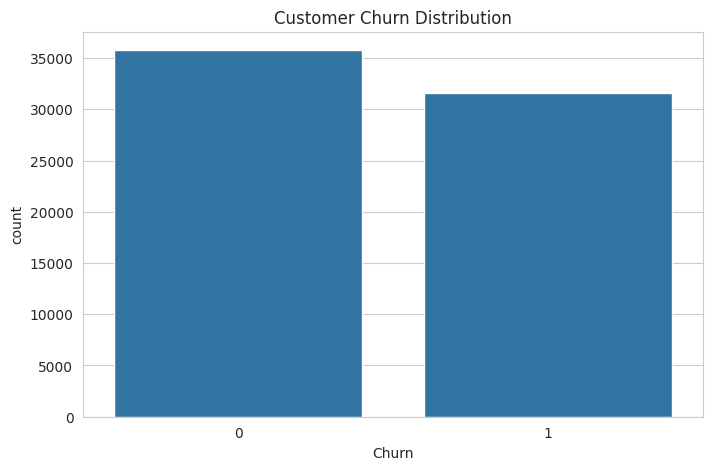

In [6]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

The churn distribution shows that the number of non-churn customers is slightly higher than churned customers, indicating a relatively balanced dataset suitable for classification modeling.**bold text**

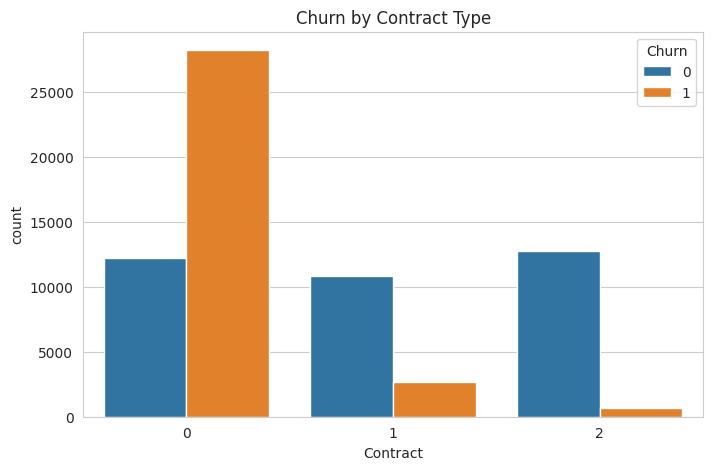

In [7]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")
plt.show()

The churn distribution shows that the number of non-churn customers is slightly higher than churned customers, indicating a relatively balanced dataset suitable for classification modeling.**bold text**

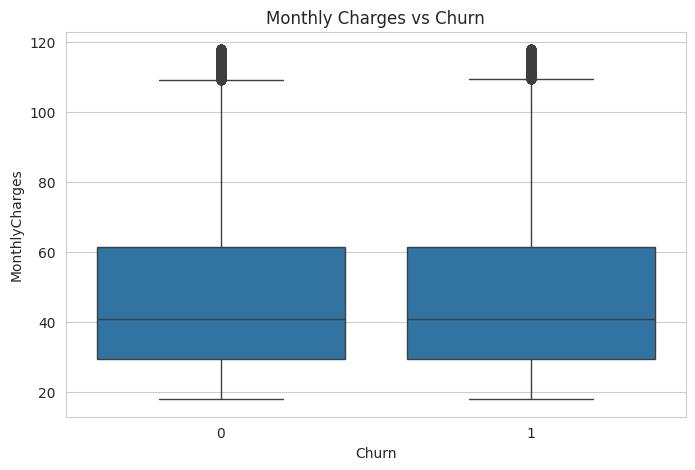

In [8]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

Customers with higher monthly charges appear slightly more likely to churn, suggesting that pricing may influence customer retention.**bold text**

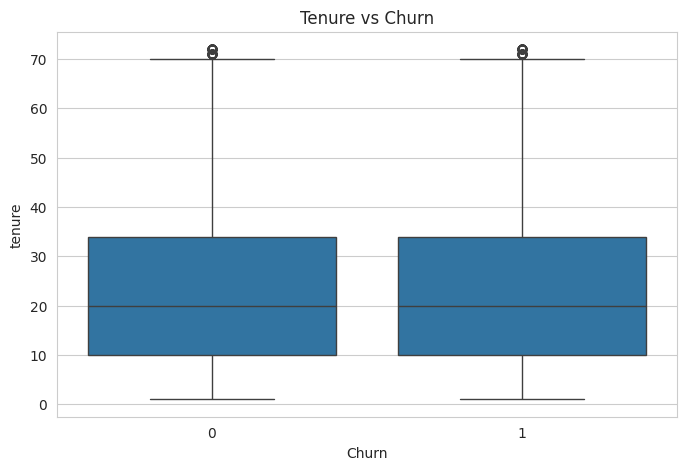

In [9]:
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")
plt.show()

Customers with higher monthly charges appear slightly more likely to churn, suggesting that pricing may influence customer retention.**bold text**

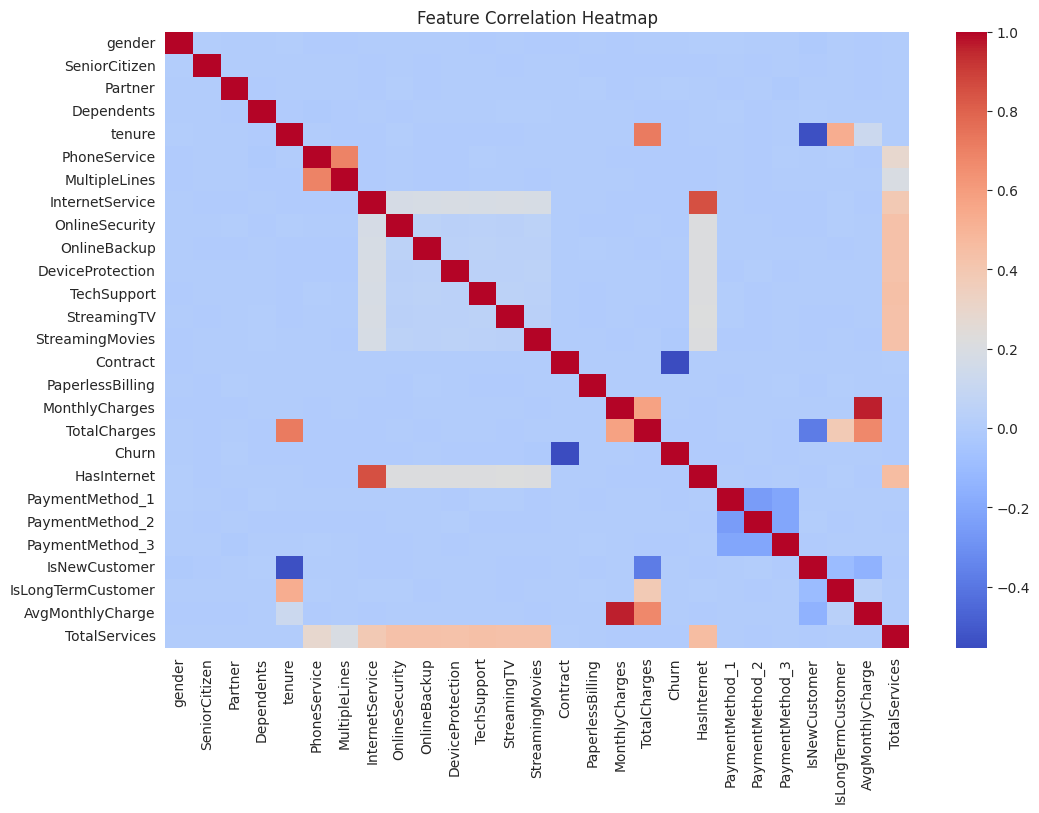

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

Customers with shorter tenure are more likely to churn, indicating that new customers have a higher risk of leaving compared to long-term subscribers.**bold text**

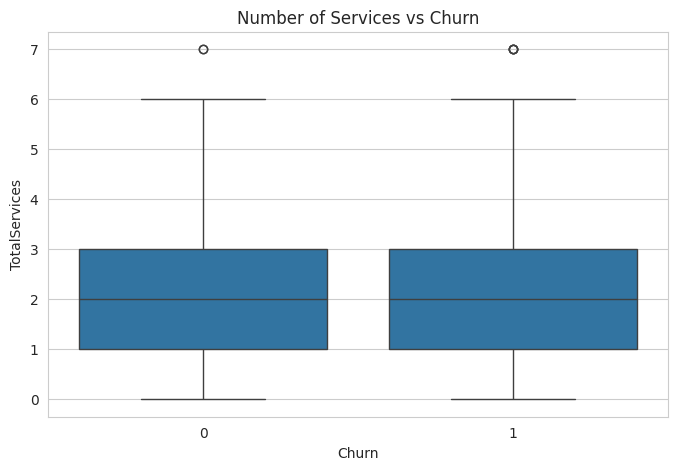

In [11]:
sns.boxplot(x="Churn", y="TotalServices", data=df)

plt.title("Number of Services vs Churn")
plt.show()

The distribution of the total number of services appears very similar for both churned and non-churned customers. This suggests that the number of subscribed services does not strongly influence customer churn in this dataset.**bold text**

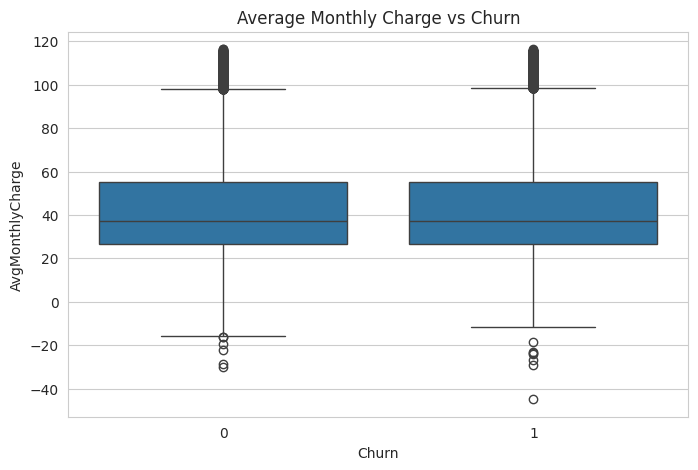

In [12]:
sns.boxplot(x="Churn", y="AvgMonthlyCharge", data=df)

plt.title("Average Monthly Charge vs Churn")
plt.show()

The distribution of the average monthly charge is very similar between churned and non-churned customers. This suggests that the average monthly spending does not strongly influence customer churn in this dataset.**bold text**

The exploratory data analysis reveals several key factors influencing customer churn. Customers with month-to-month contracts show significantly higher churn rates compared to those with long-term contracts. Additionally, customers with higher monthly charges appear more likely to churn, suggesting that pricing plays an important role in customer retention. Tenure also shows a clear relationship with churn, as newer customers are more likely to leave than long-term subscribers. Furthermore, customers who subscribe to multiple services tend to remain with the company longer, indicating stronger engagement. Overall, contract type, tenure, pricing, and service usage appear to be the most important factors affecting customer churn.**bold text**